In [109]:
import numpy as np
import matplotlib.pyplot as plt
import math

def f(x):
    return np.sin(x) # define the integrand

a, b = 0, np.pi # bounds of integration

N = 100000 # set number of random samples

x_random = np.random.uniform(a, b, N) # generate N uniform random samples

int_estimate = (b - a) * np.mean(f(x_random)) # plug random samples into f(x) and estimate the integral

print(f"Monte Carlo Estimate: {int_estimate:.4f}")

Monte Carlo Estimate: 2.0035


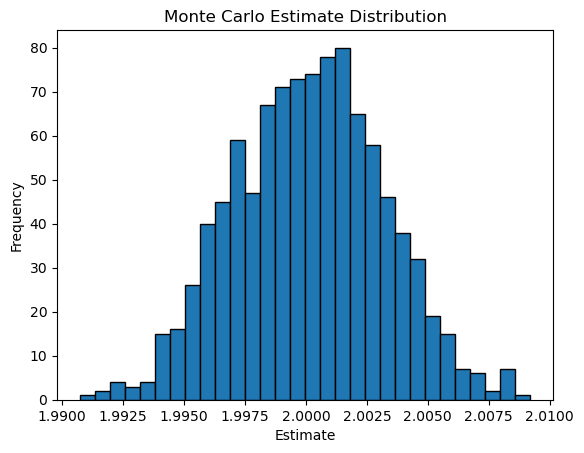

In [111]:
estimates = [] # empty list to hold estimates

for i in range(n+1):
    x_samples = np.random.uniform(a, b, N)
    estimates.append((b - a) * np.mean(f(x_samples)))

# histogram plot
plt.hist(estimates, bins=30, edgecolor='black')
plt.title("Monte Carlo Estimate Distribution")
plt.xlabel("Estimate")
plt.ylabel("Frequency")
plt.show()

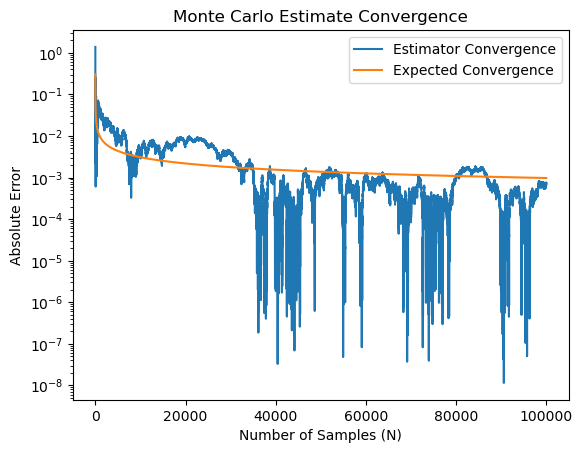

In [119]:
x = 2 # exact value of integral

estimates = []

x_random = np.random.uniform(a, b, N) # generate new array of random uniform samples

sample_sum = 0 # initialize running sum of function values of samples
for i in range(N):
    sample_sum += f(x_random[i]) # add the function value of the next sample
    int_estimate = (b - a) * (sample_sum / (i + 1)) # MC estimate for current samples
    estimates.append(int_estimate)

# Estimator Convergence/Error |desired_value - achieved value|
convergence = [abs(x-est) for est in estimates]

# Standard deviation of the distribution 
# The expected convergence is not just 1/sqrt(N), it's std(f)/sqrt(N)
sigma = np.std(np.sin(x_random))
expected_convergence = [(b-a)*sigma/math.sqrt(i) for i in range(1, N+1)]

# Convergence Plot
# Semilogy puts the y-axis into log-scale. Easier to see value fluctuations.
plt.semilogy(range(1, N+1), convergence)
plt.semilogy(range(1, N+1), expected_convergence)
plt.legend(["Estimator Convergence", "Expected Convergence"])
plt.title("Monte Carlo Estimate Convergence")
plt.xlabel("Number of Samples (N)")
plt.ylabel("Absolute Error")
plt.show()

In [121]:
def f(x, y, z):
    return x**2 + y**2 + z**2 # define distribution we wish to estimate

a, b, d = 0, 1, 3 # set domain as [0, 1]x[0, 1]x[0, 1]

N = 10000 # set number of samples

samples = np.random.uniform(a, b, (N, d)) # generate random samples from uniform domain 

# parse samples by dimension
x_samples = samples[:, 0]
y_samples = samples[:, 1]
z_samples = samples[:, 2]

# plug random samples into function and use MC estimator
estimate = (b - a)**d * np.mean(f(x_samples, y_samples, z_samples))

print(f"Monte Carlo Estimate: {estimate:.4f}")

Monte Carlo Estimate: 1.0000


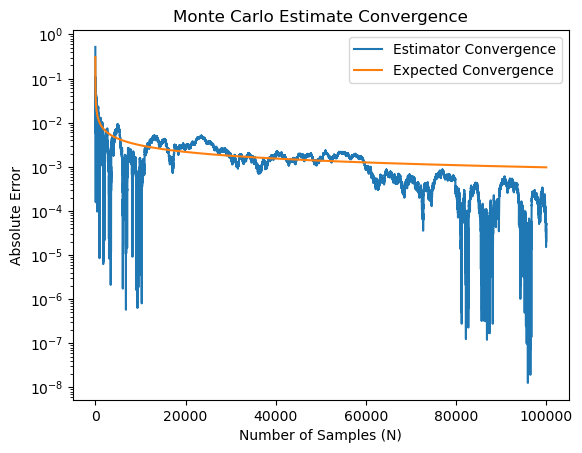

In [143]:
# define the function we wish to estimate
def f(x, y, z):
    return x**2 + y**2 + z**2

# set domain as [0, 1]x[0, 1]x[0, 1]
a, b = 0, 1

# the dimension of the domain
d = 3

# set number of random samples
N = 100000

# empty list for estimates 
estimates = []

# Create the random samples
samples = np.random.uniform(a, b, (N, d))
# Pass the samples through f(x, y, z)
f_samples = f(samples[:, 0], samples[:, 1], samples[:, 2])
cumulative_sample_sum = np.cumsum(f_samples) # Finds the cumulative sum of the f_samples
vol = (b-a)**d

# Find the estimates
estimates = [vol*(cumulative_sample_sum[i]/(i+1)) for i in range(N)]

# Find the standard deviation of the f_samples to model our expexted convergence
# Expected convergence = std(f)/N
sigma = np.std(f_samples, ddof = 1) # ddof = 1 sets the degrees of freedom to 1

# exact integration
x = 1

# Estimator Convergence (desired_value - achieved value)
convergence = [abs(x-est) for est in estimates]

# Standard deviation of the distribution 
sigma = np.std(np.sin(x_random))
expected_convergence = [sigma/math.sqrt(i) for i in range(1, N+1)]

# convergence plot
plt.semilogy(range(1, N+1), convergence) # Puts the y-axis into log scale
plt.semilogy(range(1, N+1), expected_convergence)
plt.legend(["Estimator Convergence", "Expected Convergence"])
plt.title("Monte Carlo Estimate Convergence")
plt.xlabel("Number of Samples (N)")
plt.ylabel("Absolute Error")
plt.show()